# Part 1: Gender Ratio Classification
This notebook covers **Part 1.0 (EDA)** and provides a **structured skeleton for Part 1.1**.

Datasets:
- worldbank_gender_2021.csv
- countries_regions.xlsx

In [1]:
import os
os.chdir('/Users/thammapatrattanataipop/year3term2/stat/project')
os.getcwd()

'/Users/thammapatrattanataipop/year3term2/stat/project'

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


## 2. Load Datasets

In [3]:
df_gender = pd.read_csv('worldbank_gender_2021.csv')
df_region = pd.read_excel('countries_regions.xlsx')

df_gender.head(), df_region.head()

(     Country Name  Year  \
 0     Afghanistan  2021   
 1         Albania  2021   
 2         Algeria  2021   
 3  American Samoa  2021   
 4         Andorra  2021   
 
    Agricultural irrigated land (% of total agricultural land)  \
 0                                               6.51            
 1                                              16.54            
 2                                                NaN            
 3                                                NaN            
 4                                                NaN            
 
    Agricultural land (% of land area)  \
 0                               58.74   
 1                               41.47   
 2                               17.35   
 3                               14.50   
 4                               39.91   
 
    Agriculture, forestry, and fishing, value added (% of GDP)  \
 0                                              33.60            
 1                                            

## 3. Merge Datasets

In [4]:
print(df_gender.columns)
print(df_region.columns)

Index(['Country Name', 'Year',
       'Agricultural irrigated land (% of total agricultural land)',
       'Agricultural land (% of land area)',
       'Agriculture, forestry, and fishing, value added (% of GDP)',
       'Arable land (% of land area)', 'Cereal yield (kg per hectare)',
       'Crop production index (2014-2016 = 100)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       'Food production index (2014-2016 = 100)',
       ...
       'Merchandise imports (current US$)', 'Merchandise trade (% of GDP)',
       'Contributing family workers, female (% of female employment) (modeled ILO estimate)',
       'Contributing family workers, male (% of male employment) (modeled ILO estimate)',
       'Firms with female participation in ownership (% of firms)',
       'Firms with female top manager (% of firms)',
       'Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)',
       'Proportion of time spent on unpaid domestic and

In [5]:
df = pd.merge(
    df_gender,
    df_region,
    left_on='Country Name',
    right_on='CountryName',
    how='inner'
)

df.shape

(214, 199)

## 4. Initial Data Inspection

In [6]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Columns: 199 entries, Country Name to ThirdWorld
dtypes: float64(194), int64(1), object(4)
memory usage: 332.8+ KB


,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",Gender Ratio Class,CountryName,Region,ThirdWorld
count,214,214.0,41.000000,207.000000,189.000000,204.000000,176.000000,192.000000,185.000000,192.000000,...,184.000000,5.000000,5.000000,5.000000,5.000000,4.000000,184.000000,214,214,214
unique,214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,214,13,2
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Afghanistan,Africa,No
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,53,168
mean,NaN,2021.0,13.924390,37.323913,10.034074,13.971176,3772.440909,108.080208,157.809514,108.724583,...,5.118315,42.060000,20.540000,16.264000,7.032000,56.125000,2.913043,NaN,NaN,NaN
std,NaN,0.0,18.196428,22.307676,10.045074,13.791468,3456.407558,19.599674,272.182991,17.316173,...,7.155561,14.168027,6.859883,1.748379,3.896334,20.991645,1.445945,NaN,NaN,NaN
min,NaN,2021.0,0.000000,0.500000,0.020000,0.050000,16.300000,53.890000,0.000000,65.740000,...,0.000000,26.900000,14.200000,14.060000,3.710000,25.300000,1.000000,NaN,NaN,NaN
25%,NaN,2021.0,1.490000,18.785000,1.970000,3.142500,1631.200000,97.097500,18.610000,100.007500,...,0.445000,33.500000,17.600000,14.710000,3.750000,52.525000,2.000000,NaN,NaN,NaN
50%,NaN,2021.0,8.760000,38.500000,6.560000,10.240000,3040.300000,104.940000,90.360000,105.580000,...,1.810000,36.900000,18.800000,17.120000,5.240000,63.600000,3.000000,NaN,NaN,NaN
75%,NaN,2021.0,17.570000,53.240000,15.550000,20.092500,4926.600000,117.012500,177.190000,117.400000,...,7.830000,51.200000,19.900000,17.640000,10.750000,67.200000,4.000000,NaN,NaN,NaN


## 5. Missing Values Analysis

In [7]:
df.isnull().sum().sort_values(ascending=False)

School enrollment, secondary (% net)                                 214
Public private partnerships investment in ICT (current US$)          214
Strength of legal rights index (0=weak to 12=strong)                 214
Renewable internal freshwater resources per capita (cubic meters)    214
Population living in slums (% of urban population)                   214
                                                                    ... 
Population ages 15-64 (% of total population)                          0
Population ages 0-14 (% of total population)                           0
Population, total                                                      0
Population growth (annual %)                                           0
ThirdWorld                                                             0
Length: 199, dtype: int64

## 6. Target Variable Analysis

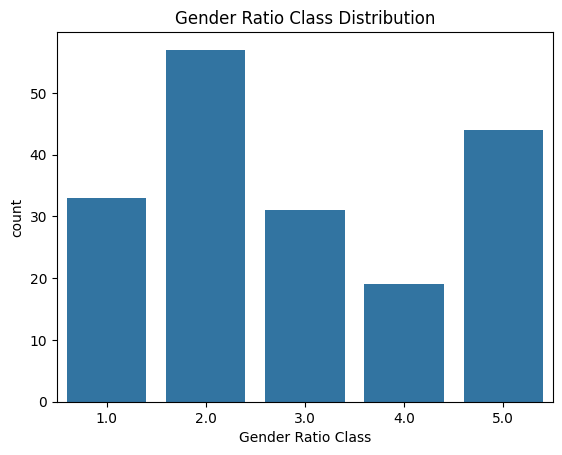

In [8]:
df['Gender Ratio Class'].value_counts(normalize=True)

sns.countplot(data=df, x='Gender Ratio Class')
plt.title('Gender Ratio Class Distribution')
plt.show()

## 7. Exploratory Data Analysis (EDA)

In [9]:
important_numeric = [
    # Labor participation
    'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)',
    'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)',

    # Unemployment
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',

    # Education
    'School enrollment, secondary (% gross)',
    'School enrollment, tertiary (% gross)'
]

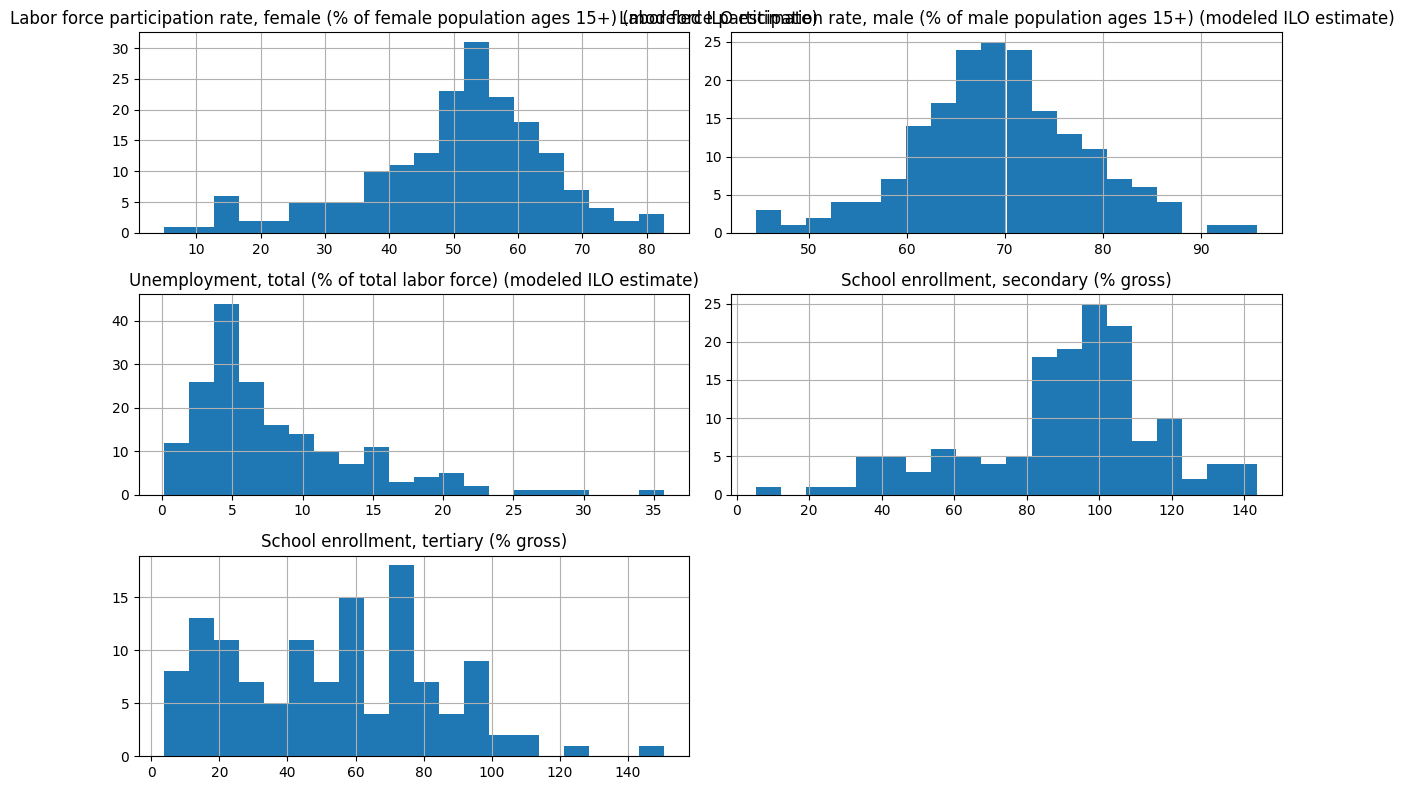

In [10]:
# Visualize distributions of selected numerical features
df[important_numeric].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

## 8. Data Cleaning & Preparation

In [11]:
#drop Gender Ratio Class
df = df.dropna(subset=['Gender Ratio Class'])

In [12]:
#drop cloumns ที่ไม่ช่วยในการทำ model
df = df.drop(columns=['Country Name', 'CountryName', 'Year'])

In [13]:
#drop columns ที่มีข้อมูลหายมากกว่า 50%
missing_ratio = df.isnull().mean()
df = df.drop(columns=missing_ratio[missing_ratio > 0.5].index)

In [14]:
#Categorical เติมด้วย mode Numeric เติมด้วย median 
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [15]:
df.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Gender Ratio Class,Region,ThirdWorld
0,58.74,33.60,12.00,2099.0,125.67,5.20,114.32,1.85,12084.40,652230.0,...,109835608.0,0.34,8.500000e+08,5.308000e+09,43.16,60.87,12.79,1.0,South Asia,Yes
1,41.47,18.36,21.89,5144.7,114.68,97.84,104.92,28.79,7889.00,27400.0,...,6384226.0,8.41,3.559000e+09,7.718000e+09,62.89,27.58,15.96,1.0,Eastern Europe,No
2,17.35,11.23,3.16,1433.7,108.76,20.68,104.83,0.82,19583.33,2381741.0,...,109835608.0,3.95,3.863700e+10,3.746600e+10,40.86,2.10,1.61,1.0,Africa,No
5,36.81,11.49,4.31,1000.1,116.22,5.61,117.50,52.98,660523.13,1246700.0,...,43596708.0,12.20,3.447200e+10,1.137900e+10,68.94,5.59,3.34,5.0,Africa,Yes
7,43.10,7.31,15.42,5193.0,107.19,62.18,108.40,10.40,284636.67,2736690.0,...,466425814.0,42.34,7.793500e+10,6.318500e+10,28.92,0.85,0.31,4.0,South America,No


In [16]:
df.info()
df.isnull().sum().sort_values(ascending=False).head()

<class 'pandas.core.frame.DataFrame'>
Index: 184 entries, 0 to 213
Columns: 109 entries, Agricultural land (% of land area) to ThirdWorld
dtypes: float64(107), object(2)
memory usage: 158.1+ KB


Agricultural land (% of land area)                    0
Age dependency ratio (% of working-age population)    0
Net migration                                         0
Life expectancy at birth, total (years)               0
Life expectancy at birth, male (years)                0
dtype: int64

## Part 1.2: Feature Extraction

In [17]:
# Separate features from the target variable
X = df.drop(columns=['Gender Ratio Class'])
y = df['Gender Ratio Class']

In [18]:
# Select numerical features for feature extraction
X_num = X.select_dtypes(include='number')

In [19]:
# Import scaler for feature standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

## 1.2.1 PCA

In [20]:
# Import PCA for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [21]:
# Import NumPy for numerical operations
import numpy as np

explained_var = np.cumsum(pca.explained_variance_ratio_)
explained_var

array([0.21712764, 0.33576796, 0.38993091, 0.43084308, 0.46784882,
       0.49912088, 0.52772215, 0.5546113 , 0.57989513, 0.60394679,
       0.62500545, 0.64436583, 0.6623079 , 0.67970822, 0.69551977,
       0.71107883, 0.72608699, 0.7396111 , 0.75270709, 0.76552428,
       0.77736472, 0.78863458, 0.79944293, 0.80980166, 0.81964582,
       0.82902476, 0.83754902, 0.84575217, 0.85374855, 0.86133101,
       0.86859912, 0.87566909, 0.8825122 , 0.88922185, 0.89529503,
       0.90114909, 0.90685076, 0.91225727, 0.91719184, 0.92203882,
       0.92659165, 0.9310218 , 0.93520582, 0.93923753, 0.94308435,
       0.94649623, 0.94985594, 0.95294052, 0.95595999, 0.95884528,
       0.9615726 , 0.96424777, 0.96683696, 0.96912898, 0.97126814,
       0.97319324, 0.9750398 , 0.9767748 , 0.97848684, 0.9800776 ,
       0.9816493 , 0.98310111, 0.9843833 , 0.98563323, 0.98686178,
       0.98792084, 0.9889355 , 0.9899373 , 0.99085475, 0.9917229 ,
       0.99255512, 0.99331743, 0.9939624 , 0.99460125, 0.99517

In [22]:
# Select number of principal components explaining at least 85% variance
n_components_pca = np.argmax(explained_var >= 0.85) + 1
n_components_pca

pca_loadings = pd.DataFrame(
    pca.components_[:n_components_pca],
    columns=X_num.columns,
    index=[f'PC{i+1}' for i in range(n_components_pca)]
)

pca_loadings

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)",Fuel exports (% of merchandise exports),High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)"
PC1,0.055266,0.155055,0.005268,-0.095695,0.073615,-0.076429,0.044528,-0.011676,-0.026999,-0.029146,...,0.176047,-0.001591,-0.089041,-0.083144,-0.113039,-0.102013,-0.105569,-0.067457,0.124755,0.124761
PC2,0.036964,0.050262,0.027177,-0.008851,0.042893,0.001629,0.048667,-0.012792,0.124940,0.167034,...,0.070667,0.007248,0.041016,0.205891,0.024387,0.215723,0.208767,-0.055181,0.068156,0.048623
PC3,0.089431,0.030636,0.108232,-0.104085,-0.108718,-0.132016,-0.154682,0.113021,0.026296,0.006354,...,0.061965,-0.150038,0.077988,0.062371,0.109600,0.064936,0.072254,0.014186,-0.008963,0.030783
PC4,-0.184750,-0.031610,-0.222629,-0.002555,0.087211,0.037799,0.135707,0.137943,0.118390,0.096648,...,0.018518,0.222428,0.070953,0.033595,-0.001171,0.030001,0.007064,0.085450,-0.018939,0.037690
PC5,-0.092577,-0.069649,-0.141546,0.000208,-0.059621,-0.031889,-0.184584,0.158733,0.251041,0.223695,...,-0.030219,0.049980,-0.186083,-0.113683,-0.155695,-0.069231,-0.086745,-0.175843,-0.088702,-0.081605
PC6,0.031148,-0.086028,-0.132817,-0.097549,0.039202,-0.071528,0.020415,-0.115045,0.130892,0.150301,...,-0.094431,0.057757,0.030872,0.006243,0.039949,0.020914,0.014810,0.099187,-0.164760,-0.178063
PC7,0.110107,-0.101294,-0.036289,-0.021933,0.107655,-0.029837,0.077958,-0.026200,-0.228074,-0.193321,...,-0.034230,-0.045281,-0.032596,0.144902,-0.042478,0.048528,0.041669,0.216806,-0.120588,-0.113014
PC8,0.257064,0.000800,0.201157,-0.047344,0.275658,-0.042584,0.296917,-0.152733,0.141991,0.138459,...,-0.006559,0.014252,-0.036651,-0.092865,-0.005941,-0.056080,-0.044530,0.065521,-0.027974,-0.034911
PC9,0.133520,0.034948,-0.013324,0.031019,0.145761,-0.002658,0.109953,-0.192963,-0.026376,0.024142,...,-0.041637,-0.018835,-0.116809,0.022495,-0.045254,0.070975,0.056589,-0.166956,-0.039890,0.004850
PC10,0.046315,-0.052080,0.111724,0.012912,0.034917,-0.054941,-0.058387,-0.099176,-0.047284,-0.018198,...,-0.027128,0.141036,-0.118582,-0.127493,0.075475,-0.069129,-0.062416,-0.120078,0.031512,0.020917


## 1.2.2 LDA

In [23]:
# Import LDA for supervised feature extraction
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y)

In [24]:
# Check the shape of transformed features after LDA
X_lda.shape

(184, 4)

In [25]:
# Extract LDA coefficients to interpret feature contributions
lda_coeff = pd.DataFrame(
    lda.coef_,
    columns=X_num.columns
)

lda_coeff

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)",Fuel exports (% of merchandise exports),High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)"
0,-0.040704,1.891701,0.081083,-0.955630,-1.404922,-0.058188,1.575210,-0.190463,-2.073629,5.579295,...,1.790422,0.931958,0.839532,-2.119012,0.463371,6.652208,-2.242467,0.273492,0.664887,-0.381225
1,0.007564,-1.398690,0.355693,-1.002571,2.657450,0.720305,-3.764681,0.309283,-1.967118,-0.717931,...,2.100450,-0.727833,-0.762204,-0.013965,-0.169725,-17.423966,12.358860,1.178062,-1.643606,1.788438
2,0.533941,0.961614,0.080429,0.068700,-0.796674,-0.765991,1.516307,0.005958,0.336522,-2.279637,...,-0.514259,-1.261064,1.165511,3.643351,-0.976026,32.369923,-27.846017,-2.568432,0.208002,-1.666562
3,0.815381,0.360587,1.332255,0.090891,1.649203,0.423860,-4.503985,1.247018,0.134018,-6.249007,...,-2.811121,-2.215591,-2.226556,3.701954,-0.153383,-22.067855,12.386462,0.378681,-1.358170,0.421423
4,-0.707554,-0.440046,-1.153554,1.927857,-2.539776,-0.532836,4.572162,-0.800498,3.808567,1.050119,...,-2.487642,2.089115,0.498063,-2.558127,0.626231,4.306019,-0.058406,-0.085189,2.070488,-1.038731
